<h1 style="text-align:center">
EDA on PeMS I5-N District 7 Station data
</h1>

First I want to start by confirming that the latitude and longitude makes sense. If we plot all the stations on a graph of latitude/longitude, we expect to see a mostly straight line. There should not be significant curves, as the road (I5-N) passes diagonally northward through the LA area.

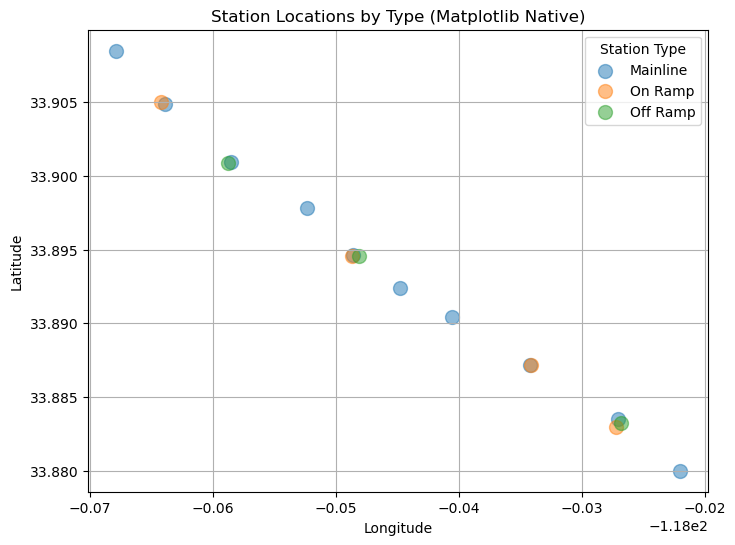

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

raw_data = pd.read_pickle("full_station_data.pkl")

station_df = (
    raw_data[["Station_ID", "Station_Type", "Latitude", "Longitude"]]
    .drop_duplicates(subset="Station_ID")
    .sort_values(by="Station_ID")
    .reset_index(drop=True)
)

# Fetch the station IDs, use that to form a new table with just station_id, latitude, longitude
station_ids = raw_data["Station_ID"].unique()

# Also fetch the station_types for iterating through
station_types = station_df["Station_Type"].unique()

# Arbitrary color selection
colors = plt.cm.tab10(range(len(station_types)))

plt.figure(figsize=(8, 6))
# Plot each group with a given color
for station_type, color in zip(station_types, colors):
    subset = station_df[station_df["Station_Type"] == station_type]
    x = subset["Longitude"]
    y = subset["Latitude"]

    # Jitter the points slightly, otherwise several stations overlap
    x_jitter = x + np.random.normal(0, 0.0005, len(x))
    y_jitter = y + np.random.normal(0, 0.0005, len(y))

    plt.scatter(
        x_jitter,
        y_jitter,
        alpha=0.5,
        label=station_type,
        color=color,
        s=100
    )

plt.title("Station Locations by Type (Matplotlib Native)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Station Type")
plt.grid(True)
plt.show()


These results look great! Nice and linear relationship between longitude and latitude, we can actually overlay this on google maps and see they align nicely. A small amount of jitter has been added to the datapoints to ensure they do not visually overlap despite being at the same geographic coordinates.

Now let's plot a grouped histogram to examine how data is missing. Only one station had a 4th lane, so we've imputed NA values for lane 4 in all stations except that one. Similarly, the on/off ramps all only have a single lane, so they contain NA values in lanes 2, 3, and 4. Plotting this grouped by station and sub-grouped by lane will enable us to explore precisely how much missing or bad data there is, as well as highlighting how we may need to proceed to ensure all this data works well together.

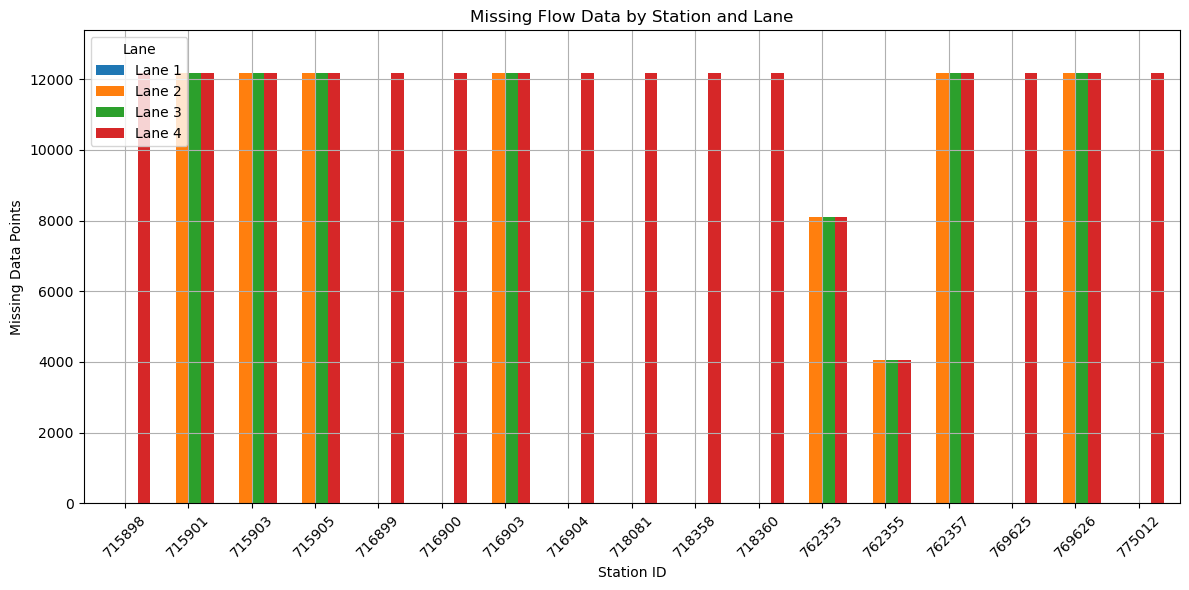

In [27]:
'''
This code was initially written by ChatGPT, later extended and modified by Drew
'''

import matplotlib.pyplot as plt
import pandas as pd

# Load
df = pd.read_pickle("full_station_data.pkl")

# Lanes to check
lanes = [1, 2, 3, 4]
col_template = "Lane {} Flow (Veh/5 Minutes)"

records = []
for station_id, group in df.groupby("Station_ID"):
    total = len(group)
    for i in lanes:
        col = col_template.format(i)
        if col in group.columns:
            # count cells that are either NaN or blank strings
            val = group[col]
            missing = ((val.isna()) | (val.astype(str).str.strip() == "")).sum()
        else:
            missing = 0
        records.append({
            "Station_ID": station_id,
            "Lane": f"Lane {i}",
            "Missing": missing
        })

missing_df = pd.DataFrame(records)

# Pivot into wide form
pivot = missing_df.pivot(index="Station_ID", columns="Lane", values="Missing").fillna(0)

# Plot
ax = pivot.plot(kind="bar", figsize=(12, 6), width=0.8)
ax.set_title("Missing Flow Data by Station and Lane")
ax.set_xlabel("Station ID")
ax.set_ylabel("Missing Data Points")
ax.set_xticklabels(pivot.index, rotation=45)
ax.legend(title="Lane")
ax.grid(True)

# Only force y≥0 if there is nonzero missing data
ymax = pivot.values.max()
if ymax > 0:
    ax.set_ylim(0, ymax * 1.1)

plt.tight_layout()
plt.show()


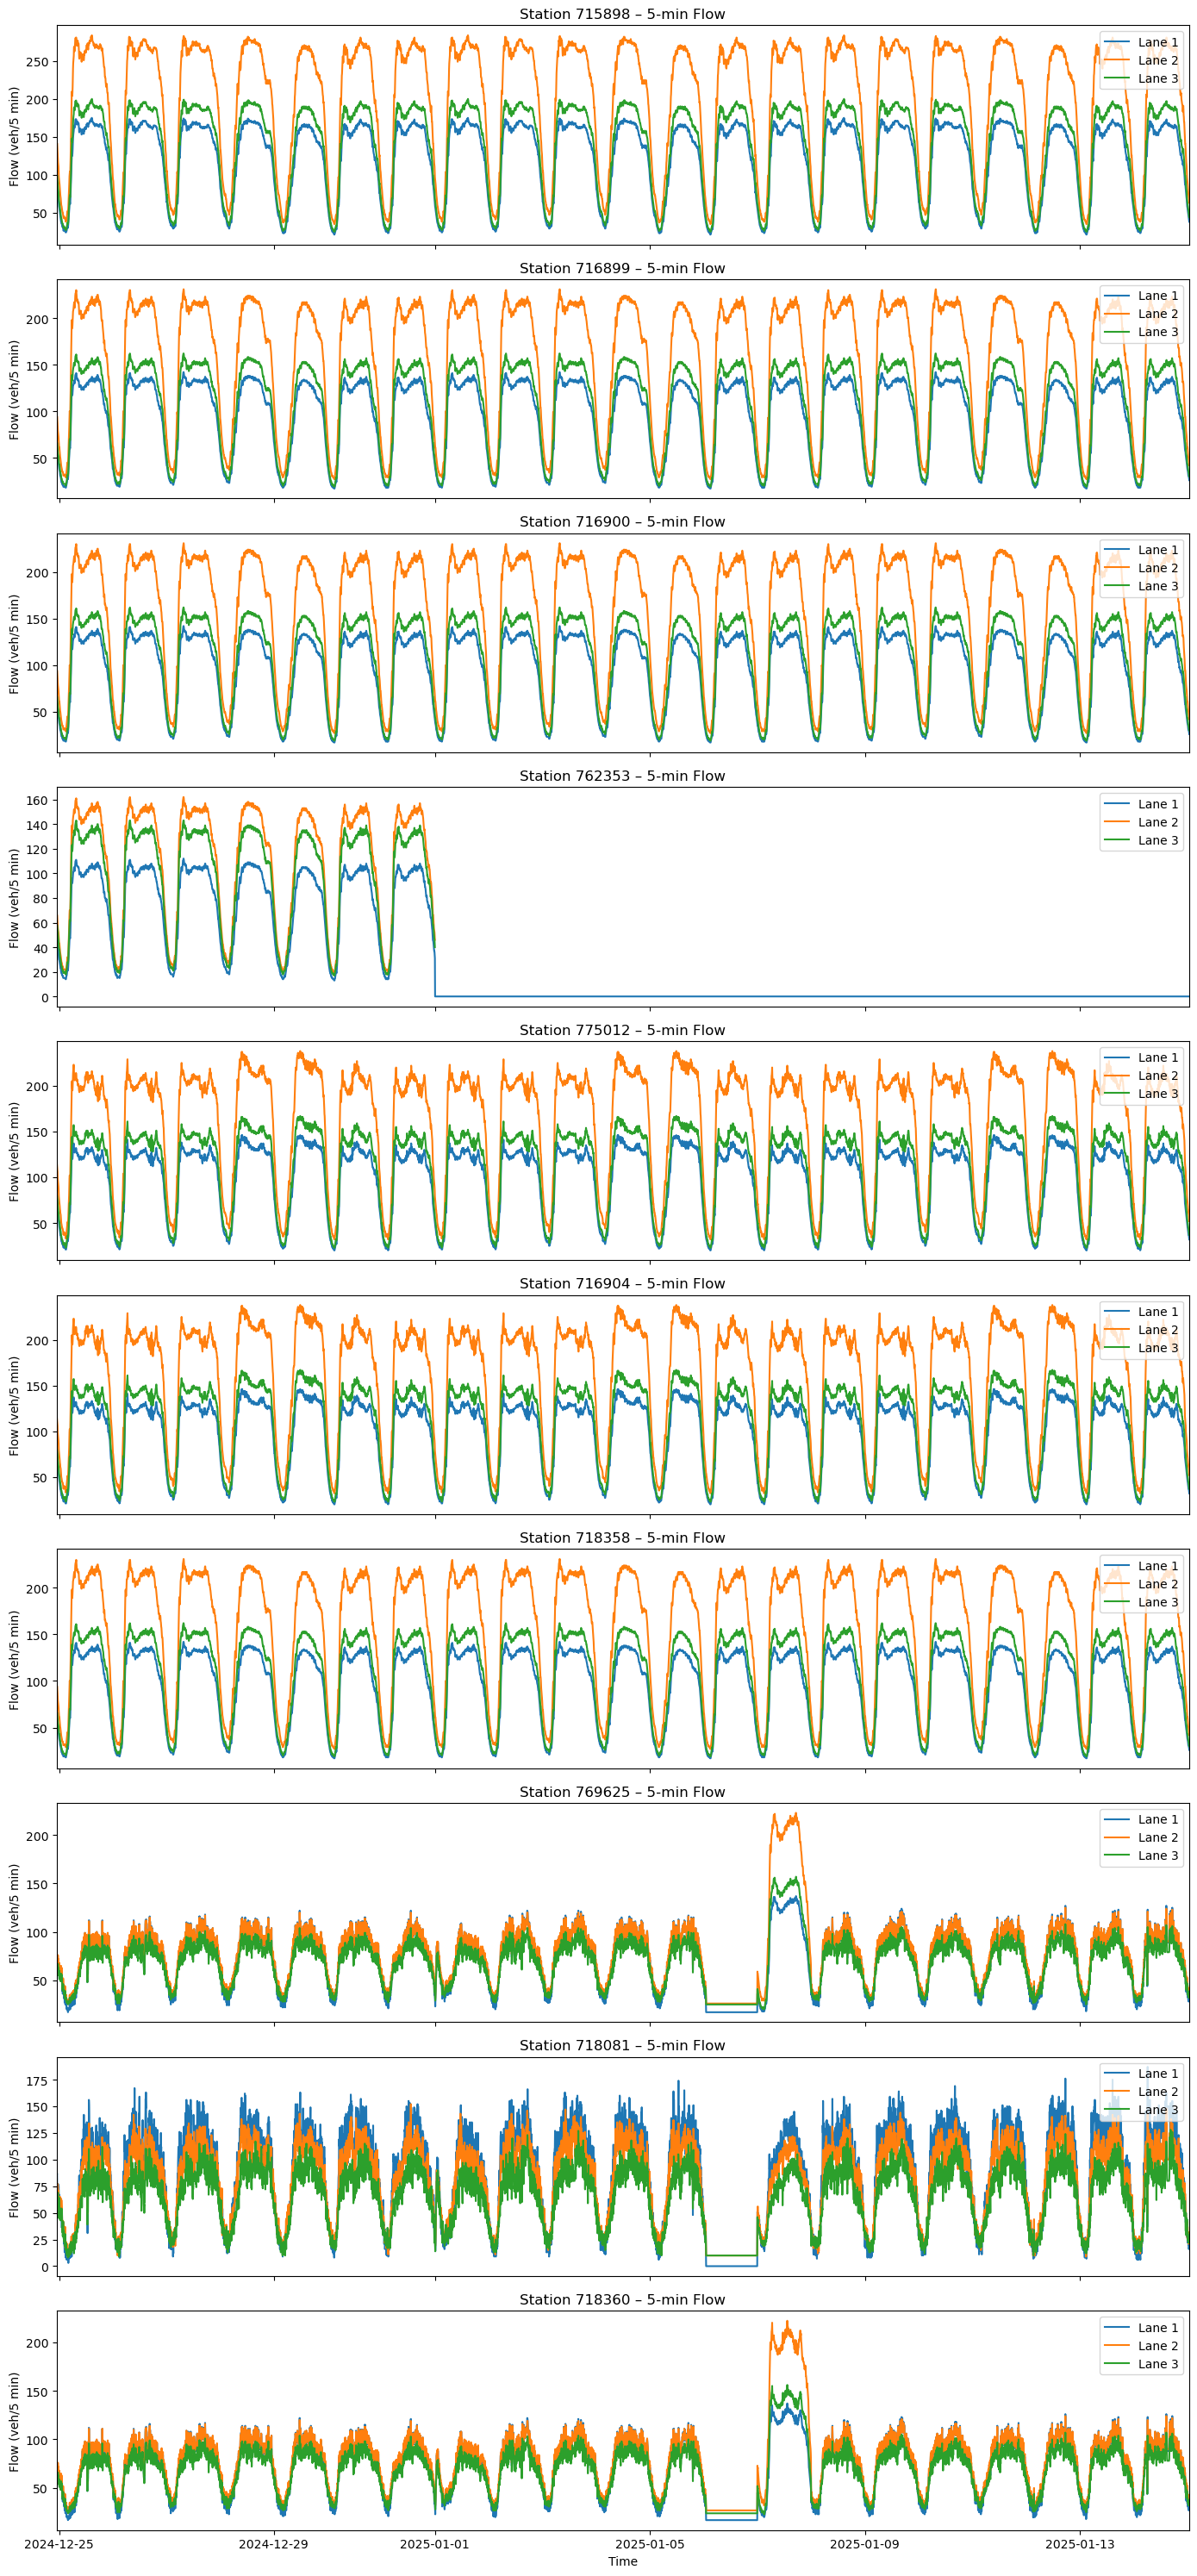

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and prep
df = pd.read_pickle("full_station_data.pkl")
df["5 Minutes"] = pd.to_datetime(df["5 Minutes"])

# Keep only mainline stations
main = df[df["Station_Type"] == "Mainline"]

stations = main["Station_ID"].unique()[:10]

# Set up subplots
n = len(stations)
fig, axes = plt.subplots(n, 1, figsize=(14, 3*n), sharex=True)

for ax, sid in zip(axes, stations):
    sub = main[main["Station_ID"] == sid].sort_values("5 Minutes")
    # Plot lanes 1–3
    for lane in [1, 2, 3]:
        col = f"Lane {lane} Flow (Veh/5 Minutes)"
        if col in sub.columns:
            ax.plot(sub["5 Minutes"], sub[col], label=f"Lane {lane}")
    ax.set_title(f"Station {sid} – 5-min Flow")
    ax.set_ylabel("Flow (veh/5 min)")
    ax.legend(loc="upper right")

# Final touches
axes[-1].set_xlabel("Time")

xmin = main["5 Minutes"].min()
xmax = main["5 Minutes"].max()
for ax in axes:
    ax.set_xlim([xmin, xmax])

plt.tight_layout()
plt.savefig("3_week_flow.png")
plt.show()

Overall min-flow hour: 3 → 23.09206349206349
Overall max-flow hour: 14 → 118.39325396825397

Per-station peak hours (1–23):
Station_ID  715898  716899  716900  716904  718081  718358  718360  762353  \
Peak_Hour       14      14      14      12      16      14      16      14   

Station_ID  769625  775012  
Peak_Hour       16      12  

Per-station low hours (1–23):
Station_ID  715898  716899  716900  716904  718081  718358  718360  762353  \
Low_Hour         3       2       2       3       3       2       3       2   

Station_ID  769625  775012  
Low_Hour         3       3  

Ramp station IDs found: [715901 762355 715903 716903 715905 769626 762357]

=== Main 769625 vs Ramp 769626 ===
  → RampFlow nonzero <10 readings (0), skipping.

=== Main 718081 vs Ramp 762357 ===
  Pearson r = 0.702
  Cross-corr lags –3…+3: {-3: np.float64(0.6926178104169479), -2: np.float64(0.6930877727915845), -1: np.float64(0.6973556938266745), 0: np.float64(0.7016234307926206), 1: np.float64(0.6999765157938

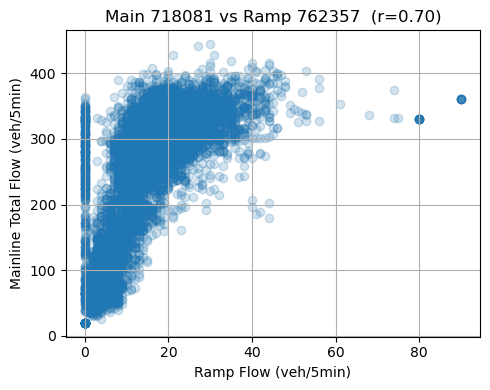

In [2]:
'''
After I wrote the above analysis and provided it to ChatGPT, I had it help me write this section to expand on and verify the analysis I performed.
This code is entirely written by ChatGPT.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load & prep ------------------------------------------------------------
df = pd.read_pickle("full_station_data.pkl")
df["5 Minutes"] = pd.to_datetime(df["5 Minutes"])

# --- A) Rush‐hour & trough hours (Mainline only, exclude hour=0) ------------
# Filter to mainline stations
mainline = df[df["Station_Type"] == "Mainline"].copy()
mainline["hour"] = mainline["5 Minutes"].dt.hour

# Global mean Lane-1 flow by hour
hourly = mainline.groupby("hour")["Lane 1 Flow (Veh/5 Minutes)"]\
                 .mean()\
                 .sort_index()
valid = hourly.loc[hourly.index != 0]

print("Overall min-flow hour:", hourly.idxmin(), "→", hourly.min())
print("Overall max-flow hour:", valid.idxmax(), "→", valid.max())

# Per-station mean by (Station_ID, hour)
station_hourly = (
    mainline
    .groupby(["Station_ID", "hour"])["Lane 1 Flow (Veh/5 Minutes)"]
    .mean()
    .reset_index(name="mean_flow")
)

# Exclude hour 0 for peak/trough
sh = station_hourly[station_hourly["hour"] != 0]

# Peak hour per station
peak = (
    sh.loc[sh.groupby("Station_ID")["mean_flow"].idxmax()]
    .set_index("Station_ID")["hour"]
)

# Low hour per station
low = (
    sh.loc[sh.groupby("Station_ID")["mean_flow"].idxmin()]
    .set_index("Station_ID")["hour"]
)

print("\nPer-station peak hours (1–23):")
print(peak.to_frame("Peak_Hour").T)
print("\nPer-station low hours (1–23):")
print(low.to_frame("Low_Hour").T)

# --- C+D) Merge & correlate with actual ramps -----------------------------
# Build ramp_df from on/off-ramps
ramp_df = df[df["Station_Type"].isin(["On Ramp", "Off Ramp"])][
    ["5 Minutes", "Station_ID", "Lane 1 Flow (Veh/5 Minutes)"]
].rename(columns={"Lane 1 Flow (Veh/5 Minutes)": "RampFlow"})

print("\nRamp station IDs found:", ramp_df["Station_ID"].unique())

# Define mainline↔ramp pairs to test
pairs = {
    769625: 769626,  # Mainline 769625 ↔ its off-ramp 769626
    718081: 762357,  # Mainline 718081 ↔ (re-labeled) on-ramp 762357
}

for main_id, ramp_id in pairs.items():
    print(f"\n=== Main {main_id} vs Ramp {ramp_id} ===")
    # Mainline lanes 1–3
    cols_main = [f"Lane {i} Flow (Veh/5 Minutes)" for i in (1,2,3)]
    m = df.loc[df.Station_ID == main_id, ["5 Minutes"] + cols_main]
    # Ramp lane-1 flow
    r = ramp_df.loc[ramp_df.Station_ID == ramp_id, ["5 Minutes", "RampFlow"]]
    
    # Align on timestamp
    merged = pd.merge(m, r, on="5 Minutes", how="inner")
    if merged.empty:
        print("  → No overlapping timestamps, skipping.")
        continue

    # Require at least some nonzero ramp readings
    nz = merged["RampFlow"] != 0
    if nz.sum() < 10:
        print(f"  → RampFlow nonzero <10 readings ({nz.sum()}), skipping.")
        continue

    # Sum mainline lanes into TotalMain
    merged["TotalMain"] = merged[cols_main].sum(axis=1)

    # Pearson correlation
    r_val = merged["RampFlow"].corr(merged["TotalMain"])
    print(f"  Pearson r = {r_val:.3f}")

    # Cross-correlation at lags –3…+3
    xcorr = {
        lag: merged["RampFlow"].corr(merged["TotalMain"].shift(lag))
        for lag in range(-3, 4)
    }
    print("  Cross-corr lags –3…+3:", xcorr)

    # Scatter plot
    plt.figure(figsize=(5,4))
    plt.scatter(merged["RampFlow"], merged["TotalMain"], alpha=0.05)
    plt.title(f"Main {main_id} vs Ramp {ramp_id}  (r={r_val:.2f})")
    plt.xlabel("Ramp Flow (veh/5min)")
    plt.ylabel("Mainline Total Flow (veh/5min)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


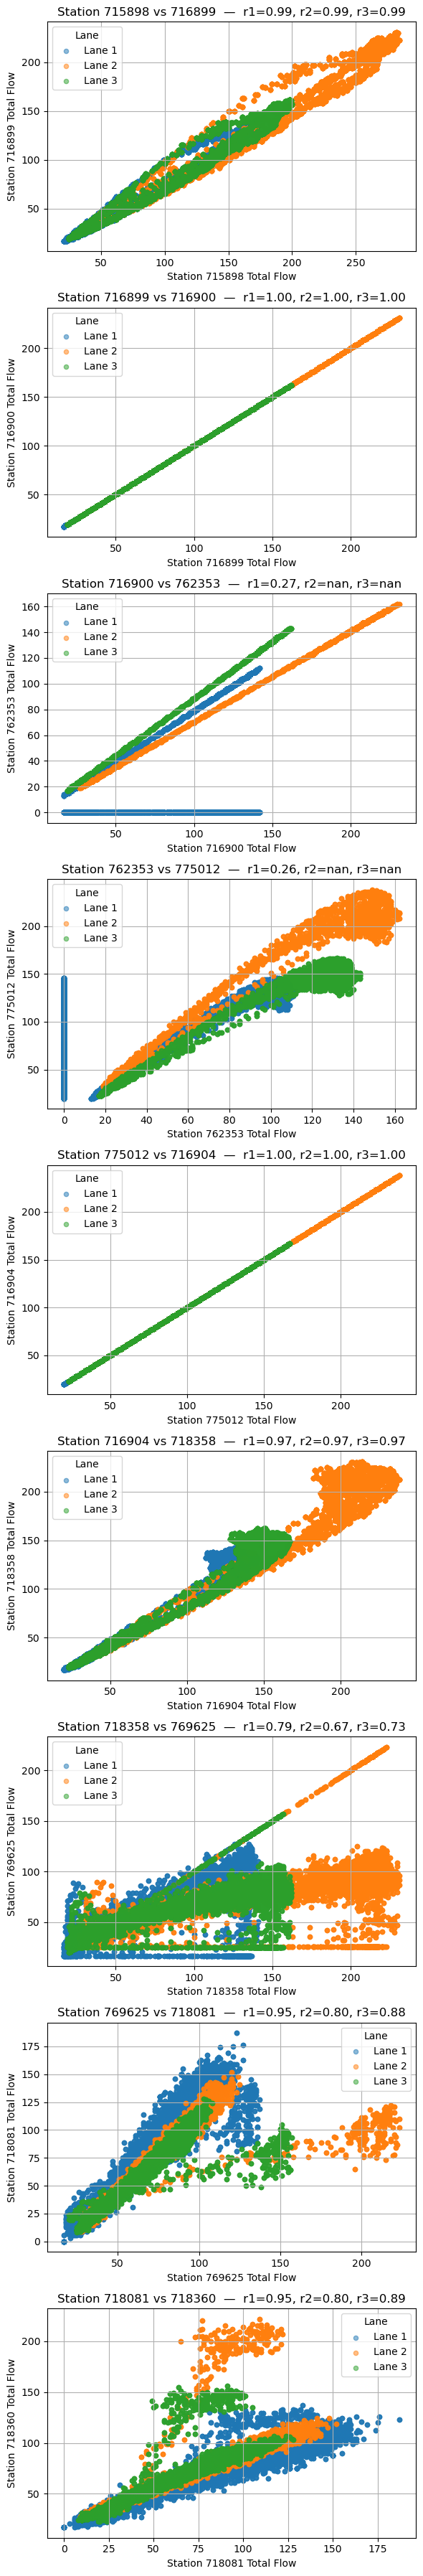

In [3]:
'''
This is code I wrote prior to getting a little lost in the sauce with matplotlib.
  Ended up turning to chatgpt and having it rework my code into something that plots.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_pickle("full_station_data.pkl")

# Drop non-mainline entries
df = df[df["Station_Type"] == "Mainline"]

coordinate_order = df["Latitude"].unique().sort()

# (0, 1), (1, 2) (2, 3) (3, 4), (4, 5), (5, 6), (6, 7),  (7, 8), (8, 9)
for i in [0, 1, 2, 3, 4, 5, 6, 7, 8]:
  x1 = df[df["Latitude"] == coordinate_order[i]]
  x2 = df[df["Latitude"] == coordinate_order[i + 1]]'''

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load & filter
df = pd.read_pickle("full_station_data.pkl")
df["5 Minutes"] = pd.to_datetime(df["5 Minutes"])
main = df[df["Station_Type"] == "Mainline"]

# Order stations by latitude
station_coords = (
    main[["Station_ID","Latitude"]]
    .drop_duplicates()
    .sort_values("Latitude")
)
station_order = station_coords["Station_ID"].tolist()

# Prepare subplots for each adjacent pair
n_pairs = len(station_order) - 1
fig, axes = plt.subplots(n_pairs, 1, figsize=(6, 4 * n_pairs), sharex=False)

for ax, i in zip(axes, range(n_pairs)):
    s1 = station_order[i]
    s2 = station_order[i+1]

    # Extract lane flows for both stations
    cols = [f"Lane {j} Flow (Veh/5 Minutes)" for j in (1,2,3)]
    d1 = main.loc[main.Station_ID==s1, ["5 Minutes"] + cols]
    d2 = main.loc[main.Station_ID==s2, ["5 Minutes"] + cols]

    # Align on time
    merged = pd.merge(d1, d2, on="5 Minutes", suffixes=(f"_{s1}", f"_{s2}"))

    # Plot each lane
    for lane, color in zip((1,2,3), plt.rcParams['axes.prop_cycle'].by_key()['color']):
        c1 = f"Lane {lane} Flow (Veh/5 Minutes)_{s1}"
        c2 = f"Lane {lane} Flow (Veh/5 Minutes)_{s2}"
        ax.scatter(
            merged[c1],
            merged[c2],
            alpha=0.5,
            label=f"Lane {lane}",
            color=color,
            s=20
        )

    # Compute per‐lane Pearson r’s
    r_vals = {
        lane: np.corrcoef(
            merged[f"Lane {lane} Flow (Veh/5 Minutes)_{s1}"],
            merged[f"Lane {lane} Flow (Veh/5 Minutes)_{s2}"]
        )[0,1]
        for lane in (1,2,3)
    }

    ax.set_title(
        f"Station {s1} vs {s2}  —  " +
        ", ".join(f"r{lane}={r:.2f}" for lane,r in r_vals.items())
    )
    ax.set_xlabel(f"Station {s1} Total Flow")
    ax.set_ylabel(f"Station {s2} Total Flow")
    ax.legend(title="Lane")
    ax.grid(True)

plt.tight_layout()
plt.show()
